Connecting to your Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detected a direct folder path on Google Drive.

Dataset target locked: /content/drive/MyDrive/Formula One Cars

Building Training and Validation Datasets...

Constructors successfully identified (8 classes):
['AlphaTauri F1 car', 'Ferrari F1 car', 'McLaren F1 car', 'Mercedes F1 car', 'Racing Point F1 car', 'Red Bull Racing F1 car', 'Renault F1 car', 'Williams F1 car']


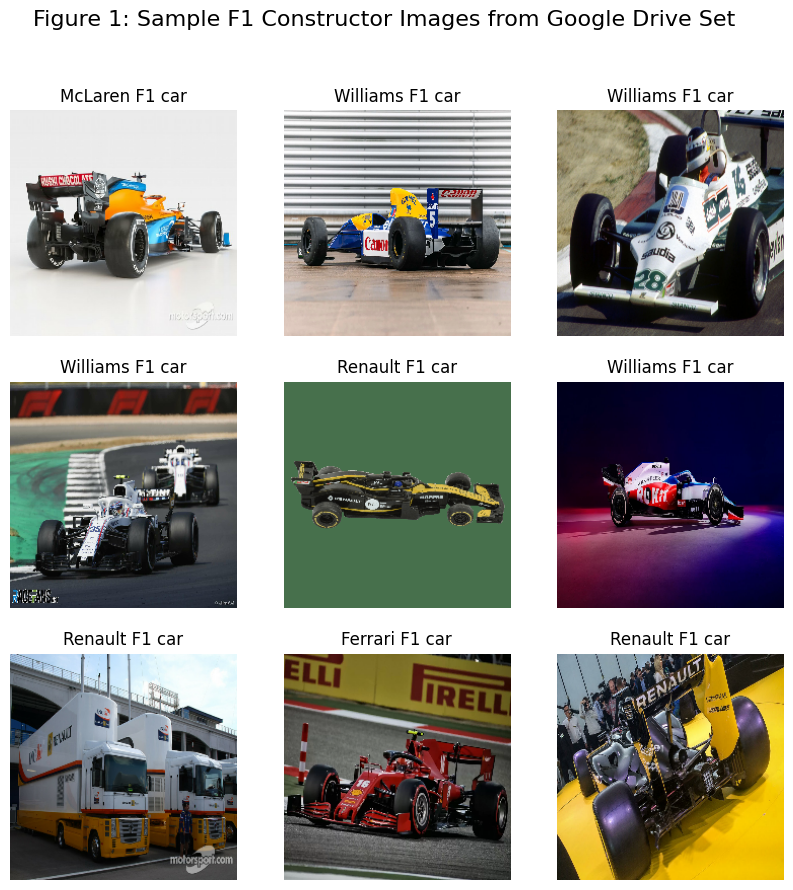

In [ ]:
import os
import zipfile
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np # Needed for the custom data loading

# 1. MOUNT GOOGLE DRIVE
print("Connecting to your Google Drive...")
drive.mount('/content/drive')

# 2. DEFINE THE PATH TO YOUR DRIVE DATA
DRIVE_PATH = '/content/drive/MyDrive/Formula One Cars'
LOCAL_EXTRACT_DIR = '/content/F1_Dataset_Local'

# 3. HANDLE ZIP VS DIRECTORY AUTOMATICALLY
if not os.path.exists(DRIVE_PATH) and os.path.exists(DRIVE_PATH + '.zip'):
    print("Detected a .zip file on Google Drive. Extracting locally for maximum training speed...")
    with zipfile.ZipFile(DRIVE_PATH + '.zip', 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    DATA_DIR = LOCAL_EXTRACT_DIR
else:
    print("Detected a direct folder path on Google Drive.")
    DATA_DIR = DRIVE_PATH

# Check for nested folders inside the target directory
subdirs = [os.path.join(DATA_DIR, d) for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
if len(subdirs) == 1:
    DATA_DIR = subdirs[0]

print(f"\nDataset target locked: {DATA_DIR}\n")

# 4. INITIALIZE THE TENSORFLOW PIPELINE (Refactored for robustness)
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

print("Building Training and Validation Datasets...")

# Get all image paths and their labels
all_image_paths = []
all_image_labels = []
class_names = sorted([d.name for d in os.scandir(DATA_DIR) if d.is_dir()]) # Get class names dynamically
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        # Filter by common image extensions and ensure it's a file
        if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(img_path)
            all_image_labels.append(class_to_idx[class_name])

# Convert to TensorFlow tensors
all_image_paths_tf = tf.constant(all_image_paths, dtype=tf.string)
all_image_labels_tf = tf.constant(all_image_labels, dtype=tf.int32)

# Create a dataset from slices and shuffle for splitting
dataset = tf.data.Dataset.from_tensor_slices((all_image_paths_tf, all_image_labels_tf))
dataset = dataset.shuffle(buffer_size=len(all_image_paths), seed=123) # Ensure consistent shuffle

# Split data into training (80%) and validation (20%)
dataset_size = len(all_image_paths)
train_size = int(0.8 * dataset_size)

train_ds_raw = dataset.take(train_size)
val_ds_raw = dataset.skip(train_size)

# Custom image loading and preprocessing function with error handling
def _decode_and_resize_img(img_path, label, img_size=(224, 224)):
    def _decode_image_py_func(path, lbl):
        try:
            img_bytes = tf.io.read_file(path)
            # Decode image, forcing 3 channels and disabling animation expansion for consistency
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.uint8) # Cast to uint8 (0-255) for plotting
            return img, lbl, True # Return image, label, and a success flag
        except (tf.errors.InvalidArgumentError, tf.errors.OutOfRangeError, tf.python.framework.errors_impl.DataLossError) as e:
            # Handle decoding errors by returning a dummy image and False flag
            # print(f"Error decoding image {path.numpy().decode('utf-8')}: {e}") # Uncomment for debugging
            return tf.zeros((img_size[0], img_size[1], 3), dtype=tf.uint8), lbl, False

    # Wrap the python function for TensorFlow graph execution
    image, label, success = tf.py_function(
        _decode_image_py_func,
        inp=[img_path, label],
        Tout=[tf.uint8, tf.int32, tf.bool]
    )

    # Set static shapes for the outputs for graph compilation
    image.set_shape([img_size[0], img_size[1], 3])
    label.set_shape([])
    success.set_shape([])

    return image, label, success

# Function to configure datasets for performance and apply custom decoding
def configure_for_performance(ds, shuffle_data=False):
    # Map the custom decoding function and filter out corrupted images
    ds = ds.map(lambda img_path, label: _decode_and_resize_img(img_path, label, IMG_SIZE), num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda image, label, success: success) # Filter out corrupted images
    ds = ds.map(lambda image, label, success: (image, label)) # Remove the success flag

    if shuffle_data:
        # Correct buffer_size for shuffle (AUTOTUNE is -1 and not valid for buffer_size here)
        ds = ds.shuffle(buffer_size=1000) # Using a fixed large buffer size
    ds = ds.batch(BATCH_SIZE)
    ds = ds.cache() # Cache after filtering to avoid re-decoding
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_dataset = configure_for_performance(train_ds_raw, shuffle_data=True)
val_dataset = configure_for_performance(val_ds_raw)
2y
print(f"\nConstructors successfully identified ({len(class_names)} classes):")
print(class_names)

# 5. GENERATE THE REPORT PLOT
plt.figure(figsize=(10, 10))
# train_dataset.take(1) will now try to get a valid batch due to filtering
for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))): # Ensure we don't try to plot more than available images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Figure 1: Sample F1 Constructor Images from Google Drive Set", fontsize=16)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Dynamically pull the exact number of constructor classes found
num_classes = len(class_names)

print(f"Building custom CNN architecture for {num_classes} classes...")

model1 = models.Sequential([
    # 1. Preprocessing: Rescale incoming uint8 data [0, 255] to [0.0, 1.0]
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # 2. First Convolutional Block (Extracts low-level edge features)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3. Second Convolutional Block (Extracts mid-level geometric patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Third Convolutional Block (Extracts high-level compound shapes)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 5. Transition to Dense classification head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Regularization factor to combat overfitting

    # 6. Final Classification Layer (Probability distribution across classes)
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model configuration
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print out the network architecture summary
model1.summary()

Building custom CNN architecture for 8 classes...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,992 (42.61 MB)

 Trainable params: 11,169,992 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. INITIALIZE THE TENSORFLOW PIPELINE (Fixed Exception Handling)
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

print("Building Training and Validation Datasets...")

# Get all image paths and their labels
all_image_paths = []
all_image_labels = []
class_names = sorted([d.name for d in os.scandir(DATA_DIR) if d.is_dir()])
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(img_path)
            all_image_labels.append(class_to_idx[class_name])

# Convert to TensorFlow tensors
all_image_paths_tf = tf.constant(all_image_paths, dtype=tf.string)
all_image_labels_tf = tf.constant(all_image_labels, dtype=tf.int32)

# Create a dataset from slices and shuffle for splitting
dataset = tf.data.Dataset.from_tensor_slices((all_image_paths_tf, all_image_labels_tf))
dataset = dataset.shuffle(buffer_size=len(all_image_paths), seed=123)

# Split data into training (80%) and validation (20%)
dataset_size = len(all_image_paths)
train_size = int(0.8 * dataset_size)

train_ds_raw = dataset.take(train_size)
val_ds_raw = dataset.skip(train_size)

# Custom image loading and preprocessing function with ROBUST error handling
def _decode_and_resize_img(img_path, label, img_size=(224, 224)):
    def _decode_image_py_func(path, lbl):
        try:
            img_bytes = tf.io.read_file(path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.uint8)
            return img, lbl, True
        except Exception as e:
            # Safely catches invalid PNGs/corrupted images and drops them from the race
            return tf.zeros((img_size[0], img_size[1], 3), dtype=tf.uint8), lbl, False

    image, label, success = tf.py_function(
        _decode_image_py_func,
        inp=[img_path, label],
        Tout=[tf.uint8, tf.int32, tf.bool]
    )

    image.set_shape([img_size[0], img_size[1], 3])
    label.set_shape([])
    success.set_shape([])

    return image, label, success

# Function to configure datasets for performance
def configure_for_performance(ds, shuffle_data=False):
    ds = ds.map(lambda img_path, label: _decode_and_resize_img(img_path, label, IMG_SIZE), num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda image, label, success: success)
    ds = ds.map(lambda image, label, success: (image, label))

    if shuffle_data:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.cache()
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_dataset = configure_for_performance(train_ds_raw, shuffle_data=True)
val_dataset = configure_for_performance(val_ds_raw)

print(f"\nConstructors successfully identified ({len(class_names)} classes):")
print(class_names)

Building Training and Validation Datasets...

Constructors successfully identified (8 classes):
['AlphaTauri F1 car', 'Ferrari F1 car', 'McLaren F1 car', 'Mercedes F1 car', 'Racing Point F1 car', 'Red Bull Racing F1 car', 'Renault F1 car', 'Williams F1 car']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Pulling the number of constructor classes dynamically from your data pipeline (8)
num_classes = len(class_names)

print(f"Constructing Baseline CNN for {num_classes} classes...")

model1 = models.Sequential([
    # 1. Standardize inputs: Rescale values from [0, 255] down to [0.0, 1.0]
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # 2. First Convolutional Block (Captures low-level lines and edges)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3. Second Convolutional Block (Captures mid-level structural textures)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Third Convolutional Block (Captures complex car component shapes)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 5. Transition to Fully Connected Classification Layer
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Prevents overfitting by forcing redundant feature learning

    # 6. Output Layer (8 nodes representing each F1 team)
    layers.Dense(num_classes, activation='softmax')
])

# Compile the configurations
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the chassis specifications
model1.summary()

Constructing Baseline CNN for 8 classes...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,992 (42.61 MB)

 Trainable params: 11,169,992 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 15

print("Engaging training sequence for Model 1...")
history1 = model1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)
print("\nTraining pass completed successfully.")

Engaging training sequence for Model 1...
Epoch 1/15
     61/Unknown 328s 5s/step - accuracy: 0.1934 - loss: 2.6234

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


61/61 ━━━━━━━━━━━━━━━━━━━━ 359s 5s/step - accuracy: 0.2342 - loss: 2.1060 - val_accuracy: 0.4158 - val_loss: 1.7101
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 302s 4s/step - accuracy: 0.3468 - loss: 1.7100 - val_accuracy: 0.4761 - val_loss: 1.5453
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 277s 5s/step - accuracy: 0.4574 - loss: 1.4672 - val_accuracy: 0.5593 - val_loss: 1.2199
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.5846 - loss: 1.1957 - val_accuracy: 0.6299 - val_loss: 1.0233
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.6812 - loss: 0.9463 - val_accuracy: 0.7734 - val_loss: 0.7673
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.7596 - loss: 0.7029 - val_accuracy: 0.8067 - val_loss: 0.6403
Epoch 7/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.8022 - loss: 0.5855 - val_accuracy: 0.8170 - val_loss: 0.6315
Epoch 8/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 249s 4s/step - accuracy: 0.8505 - loss: 0.4478 - val_accuracy: 0.8628 - val_loss: 0.

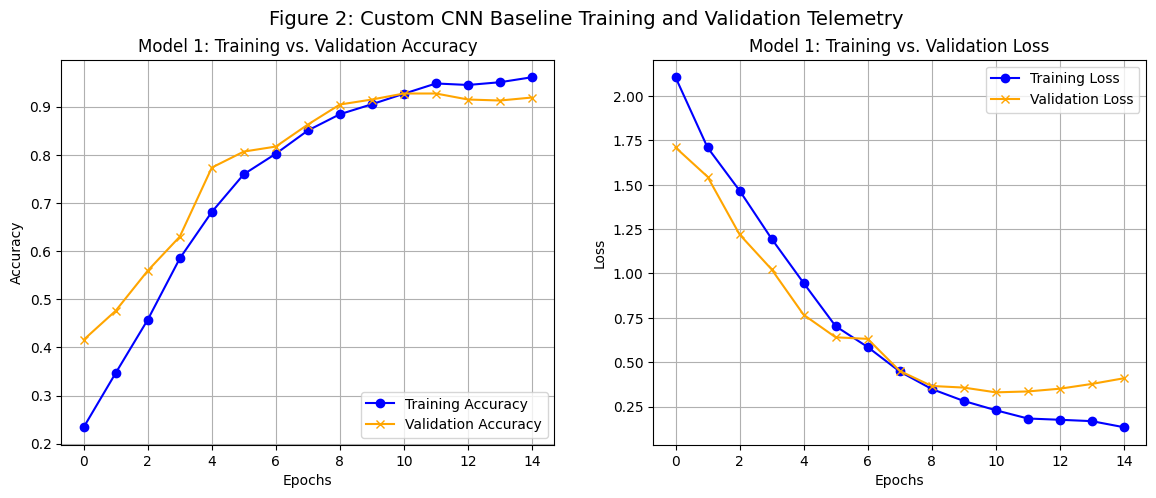

In [ ]:
import matplotlib.pyplot as plt

acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy Metric Comparisons
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='x')
plt.title('Model 1: Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss Metric Comparisons
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='x')
plt.title('Model 1: Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Figure 2: Custom CNN Baseline Training and Validation Telemetry", fontsize=14)
plt.show()

Building the ResNet-50 Aero Upgrade (Model 2)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Pulling ResNet-50 Architecture from the cloud...")

# 1. Explicitly define our 8 constructor classes to prevent memory dropouts
num_classes = 8

# 2. Load the base ResNet-50 model, pre-trained on ImageNet.
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 3. Freeze the base model so the pre-trained weights are not updated
base_model.trainable = False

# 4. Build the custom chassis around the ResNet engine
inputs = tf.keras.Input(shape=(224, 224, 3))

# ResNet-50 requires a specific mathematical preprocessing step
x = tf.keras.applications.resnet50.preprocess_input(inputs)

# Pass images through the frozen ResNet engine
x = base_model(x, training=False)

# 5. The Custom Classification Head (Your Aero Package)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Final output predicting our 8 specific F1 constructors
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Assemble the final model
model2 = tf.keras.Model(inputs, outputs)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Pulling ResNet-50 Architecture from the cloud...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ input_layer_7[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_3[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │      2,056 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

--- INITIATING SYSTEM RESET & RESNET-50 PIPELINE ---
Loading telemetry data into memory...
Data Pipeline Re-established. Constructors locked: 8

Pulling ResNet-50 Architecture from the cloud...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Engaging ResNet-50 Training Sequence...
Epoch 1/15
     61/Unknown 846s 8s/step - accuracy: 0.3178 - loss: 2.2972

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


61/61 ━━━━━━━━━━━━━━━━━━━━ 918s 9s/step - accuracy: 0.4434 - loss: 1.7287 - val_accuracy: 0.7734 - val_loss: 0.8256
Epoch 2/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 308s 5s/step - accuracy: 0.7040 - loss: 0.8911 - val_accuracy: 0.8358 - val_loss: 0.6031
Epoch 3/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 295s 5s/step - accuracy: 0.7643 - loss: 0.6973 - val_accuracy: 0.8732 - val_loss: 0.5060
Epoch 4/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 294s 5s/step - accuracy: 0.7960 - loss: 0.6074 - val_accuracy: 0.9064 - val_loss: 0.3942
Epoch 5/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 293s 5s/step - accuracy: 0.8344 - loss: 0.5092 - val_accuracy: 0.9127 - val_loss: 0.3743
Epoch 6/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 299s 5s/step - accuracy: 0.8546 - loss: 0.4569 - val_accuracy: 0.9168 - val_loss: 0.3313
Epoch 7/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 298s 5s/step - accuracy: 0.8676 - loss: 0.4102 - val_accuracy: 0.9210 - val_loss: 0.3273
Epoch 8/15
61/61 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.8785 - loss: 0.3649 - val_accuracy: 0.9335 - val_loss: 0.

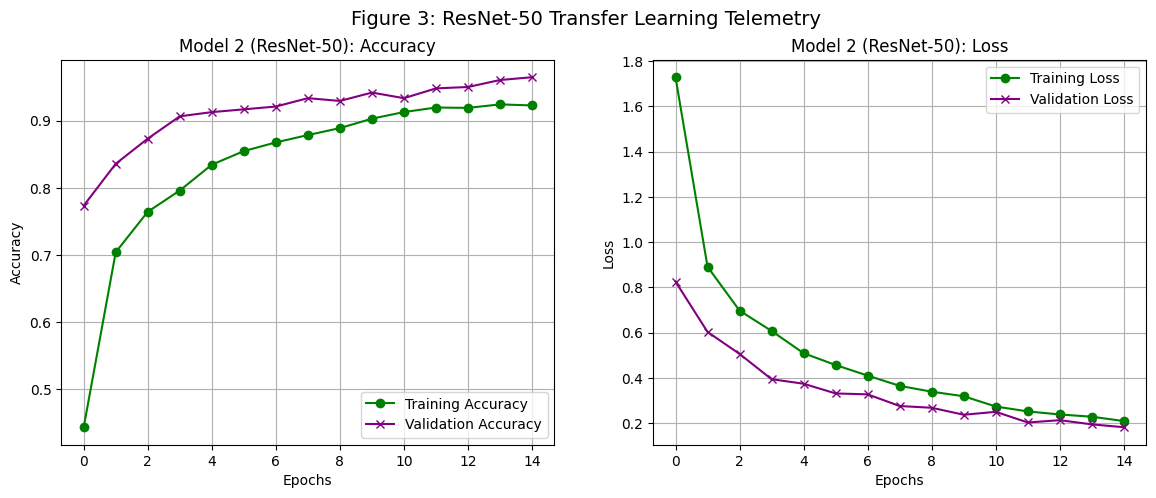

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("--- INITIATING SYSTEM RESET & RESNET-50 PIPELINE ---")

# 1. DEFINE PATH TO YOUR DATA
DATA_DIR = '/content/drive/MyDrive/Formula One Cars'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

# 2. REBUILD THE ROBUST DATA PIPELINE (Fixes the NameError)
print("Loading telemetry data into memory...")
all_image_paths = []
all_image_labels = []
class_names = sorted([d.name for d in os.scandir(DATA_DIR) if d.is_dir()])
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            all_image_paths.append(img_path)
            all_image_labels.append(class_to_idx[class_name])

all_image_paths_tf = tf.constant(all_image_paths, dtype=tf.string)
all_image_labels_tf = tf.constant(all_image_labels, dtype=tf.int32)

dataset = tf.data.Dataset.from_tensor_slices((all_image_paths_tf, all_image_labels_tf))
dataset = dataset.shuffle(buffer_size=len(all_image_paths), seed=123)

dataset_size = len(all_image_paths)
train_size = int(0.8 * dataset_size)
train_ds_raw = dataset.take(train_size)
val_ds_raw = dataset.skip(train_size)

def _decode_and_resize_img(img_path, label, img_size=(224, 224)):
    def _decode_image_py_func(path, lbl):
        try:
            img_bytes = tf.io.read_file(path)
            img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
            img = tf.image.resize(img, img_size)
            img = tf.cast(img, tf.uint8)
            return img, lbl, True
        except Exception as e:
            return tf.zeros((img_size[0], img_size[1], 3), dtype=tf.uint8), lbl, False

    image, label, success = tf.py_function(
        _decode_image_py_func, inp=[img_path, label], Tout=[tf.uint8, tf.int32, tf.bool]
    )
    image.set_shape([img_size[0], img_size[1], 3])
    label.set_shape([])
    success.set_shape([])
    return image, label, success

def configure_for_performance(ds, shuffle_data=False):
    ds = ds.map(lambda img_path, label: _decode_and_resize_img(img_path, label, IMG_SIZE), num_parallel_calls=AUTOTUNE)
    ds = ds.filter(lambda image, label, success: success)
    ds = ds.map(lambda image, label, success: (image, label))
    if shuffle_data:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.cache()
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_dataset = configure_for_performance(train_ds_raw, shuffle_data=True)
val_dataset = configure_for_performance(val_ds_raw)

print(f"Data Pipeline Re-established. Constructors locked: {len(class_names)}")

# 3. BUILD RESNET-50 ARCHITECTURE
print("\nPulling ResNet-50 Architecture from the cloud...")
num_classes = len(class_names)

base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model2 = tf.keras.Model(inputs, outputs)
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. EXECUTE TRAINING SEQUENCE
EPOCHS = 15
print("\nEngaging ResNet-50 Training Sequence...")
history2 = model2.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS)
print("\nResNet-50 Qualifying run complete. Generating Telemetry...")

# 5. GENERATE FINAL REPORT PLOTS
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc2, label='Training Accuracy', color='green', marker='o')
plt.plot(epochs_range, val_acc2, label='Validation Accuracy', color='purple', marker='x')
plt.title('Model 2 (ResNet-50): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss2, label='Training Loss', color='green', marker='o')
plt.plot(epochs_range, val_loss2, label='Validation Loss', color='purple', marker='x')
plt.title('Model 2 (ResNet-50): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Figure 3: ResNet-50 Transfer Learning Telemetry", fontsize=14)
plt.show()

--- INITIATING LIVE TELEMETRY PREDICTION ---

[SYSTEM] Image processed successfully.
[SYSTEM] Constructor Identified: Red Bull Racing F1 car
[SYSTEM] Confidence Level: 96.43%


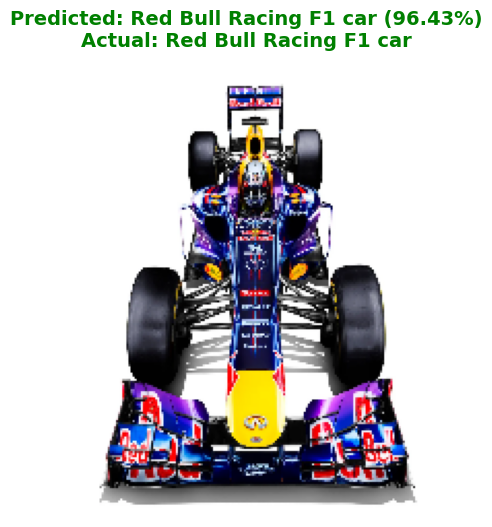

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("--- INITIATING LIVE TELEMETRY PREDICTION ---")

# Take one random batch from the validation track
for images, labels in val_dataset.shuffle(100).take(1):

    # Select the first car in the batch
    test_image = images[0]
    true_label = labels[0].numpy()

    # Preprocess the image for the ResNet-50 engine (Expand to batch of 1)
    img_array = tf.expand_dims(test_image, 0)

    # Execute the prediction
    predictions = model2.predict(img_array, verbose=0) # verbose=0 keeps the output clean
    predicted_class_index = np.argmax(predictions)

    # Extract the constructor names
    true_team = class_names[true_label]
    predicted_team = class_names[predicted_class_index]
    confidence = np.max(predictions) * 100

    # Display the visual telemetry
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.axis("off")

    # Turn text green if correct, red if the model crashes
    title_color = 'green' if true_team == predicted_team else 'red'

    plt.title(f"Predicted: {predicted_team} ({confidence:.2f}%)\nActual: {true_team}",
              color=title_color, fontsize=14, fontweight='bold')

    print(f"\n[SYSTEM] Image processed successfully.")
    print(f"[SYSTEM] Constructor Identified: {predicted_team}")
    print(f"[SYSTEM] Confidence Level: {confidence:.2f}%")

    plt.show()
    break # We only need one live prediction for the camera

In [1]:
# Save the model state
model_save_path = 'MODEL PREDICTION.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Optional: Download it directly to your Mac
from google.colab import files
files.download(model_save_path)

NameError: name 'torch' is not defined